# Georeferencing VisLoc drone images

In [ ]:
import os
import rasterio
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from PIL import Image
from shapely import affinity
from shapely.geometry import Polygon
from natsort import natsorted

In [2]:
def load_gcps(filepath, only_enabled=True):
    """
    Load GCPs from a text file with a CRS header and tabular data.
    
    Parameters
    ----------
    filepath : str
        Path to the GCP file.
    only_enabled : bool, default=True
        If True, only return GCPs where enable == 1.
    
    Returns
    -------
    world_coords : np.ndarray
        Array of world coordinates (mapX, mapY).
        Shape: (n_points, 2)
    pixel_coords : np.ndarray
        Array of pixel coordinates (sourceX, sourceY).
        Shape: (n_points, 2)
    str
        CRS string extracted from header.
    """
    with open(filepath, "r", encoding="utf-8") as f:
        lines = f.readlines()
    
    # Extract CRS from header
    crs_line = lines[0].strip()
    crs = crs_line.replace("#CRS:", "").strip() if crs_line.startswith("#CRS:") else None
    
    # Parse the rest (skip column header line)
    data = []
    for line in lines[2:]:  # start after column names
        if not line.strip():
            continue
        values = [float(v) for v in line.split(",")]
        data.append(values)
    
    arr = np.array(data)  # shape (n, 8)
    
    # Optionally filter enabled GCPs
    if only_enabled:
        arr = arr[arr[:, 4] == 1]
    
    # Split into world and pixel coords
    world_coords = np.abs(arr[:, 0:2])   # mapX, mapY
    pixel_coords = np.abs(arr[:, 2:4])   # sourceX, sourceY
    
    return world_coords, pixel_coords, crs


In [ ]:
trajectory_id = "11"
assert trajectory_id != "7", (
	"Trajectory ID 7 will not work because it doesn't have yaw, pitch and roll defined in csv")

In [53]:
trajectory_path = os.path.join("/storage/datasets/AerialLoc/UAV_VisLoc/", trajectory_id)
drone_csv_path = os.path.join(trajectory_path, f"{trajectory_id}.csv")

In [54]:
drone_csv = pd.read_csv(drone_csv_path)
drone_csv.head()

,num,filename,date,lat,lon,height,Omega,Kappa,Phi1,Phi2
0,1,11_0001.JPG,2023-10-19T10:37:59,38.809514,101.039514,1970.83,13.441590,11.631043,95.993349,90.137720
1,2,11_0002.JPG,2023-10-19T10:41:35,38.809296,101.037681,2399.98,23.623050,3.964868,10.370536,17.016847
2,3,11_0003.JPG,2023-10-19T10:47:17,38.850612,101.017318,2573.55,0.911003,1.037054,89.690813,90.424199
3,4,11_0004.JPG,2023-10-19T10:47:22,38.850607,101.018808,2573.45,1.151645,3.729955,88.991805,89.673625
4,5,11_0005.JPG,2023-10-19T10:47:27,38.850618,101.020309,2573.64,5.345696,2.360586,88.275607,89.123585


In [55]:
def load_GCP_files(trajectory_path):
	gcp_dir = os.path.join(trajectory_path, "gcps")
	gcp_files = [os.path.join(gcp_dir, f) for f in os.listdir(gcp_dir)]
	corr_image_id = [f.split(".", maxsplit=1)[0] + ".JPG" for f in os.listdir(gcp_dir)]
	return natsorted(gcp_files), natsorted(corr_image_id)

In [56]:
gcp_files, corr_image_id = load_GCP_files(trajectory_path)
print(gcp_files)
print(corr_image_id)

['/storage/datasets/AerialLoc/UAV_VisLoc/11/gcps/11_0113.JPG.points', '/storage/datasets/AerialLoc/UAV_VisLoc/11/gcps/11_0327.JPG.points']
['11_0113.JPG', '11_0327.JPG']


In [ ]:
def compute_affine_transform(px, py, X, Y):
	A = np.vstack([px, py, np.ones_like(px)]).T
	aff_x = np.linalg.lstsq(A, X, rcond=None)[0]
	aff_y = np.linalg.lstsq(A, Y, rcond=None)[0]

	M_affine = np.array([
		[aff_x[0], aff_x[1], aff_x[2]],
		[aff_y[0], aff_y[1], aff_y[2]],
		[0, 0, 1]
	])
	return M_affine

In [58]:
gcp_dict = {k: v for k, v in zip(corr_image_id, gcp_files)}

First reference image: 11_0113.JPG
New reference image found: 11_0113.JPG
New reference image found: 11_0327.JPG


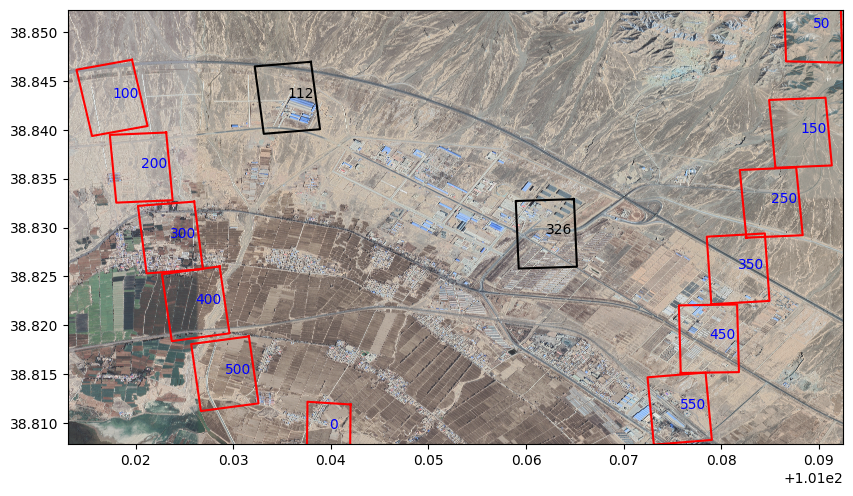

In [ ]:
plt.figure(figsize=(10, 10))

drone_boxes = []

gcp_path = gcp_files[0]
image_path = os.path.join(trajectory_path, "drone", corr_image_id[0])

world_coords, pixel_coords, _ = load_gcps(gcp_path)
px, py = pixel_coords[:, 0], pixel_coords[:, 1]
X, Y = world_coords[:, 0], world_coords[:, 1]

im = Image.open(image_path)
arr = np.array(im)

h, w, _ = arr.shape
y, x = np.indices((h, w))
coords = np.stack([x.ravel(), y.ravel(), np.ones_like(x).ravel()])

M_affine = compute_affine_transform(px, py, X, Y)
world_coords = M_affine @ coords
X_w = world_coords[0].reshape(h, w)
Y_w = world_coords[1].reshape(h, w)

tl = (X_w[0, 0], Y_w[0, 0]) # top-left corner
tr = (X_w[0, -1], Y_w[0, -1]) # top-right corner
bl = (X_w[-1, 0], Y_w[-1, 0]) # bottom-left corner
br = (X_w[-1, -1], Y_w[-1, -1]) # bottom-right corner

f = drone_csv.iloc[drone_csv.index[drone_csv['filename'] == corr_image_id[0]].tolist()[0]]

ref_box = Polygon([tl, tr, br, bl, tl])
ref_center = (f.lon, f.lat)
ref_yaw = f.Phi1
ref_roll = f.Kappa
ref_pitch = f.Omega
ref_H = f.height
print("First reference image:", f.filename)

for i, f in enumerate(drone_csv.itertuples()):
	is_ref = False
	if f.filename in gcp_dict:
		is_ref = True
		gcp_path = gcp_dict[f.filename]
		image_path = os.path.join(trajectory_path, "drone", f.filename)

		world_coords, pixel_coords, _ = load_gcps(gcp_path)
		px, py = pixel_coords[:, 0], pixel_coords[:, 1]
		X, Y = world_coords[:, 0], world_coords[:, 1]

		im = Image.open(image_path)
		arr = np.array(im)

		h, w, _ = arr.shape
		y, x = np.indices((h, w))
		coords = np.stack([x.ravel(), y.ravel(), np.ones_like(x).ravel()])

		M_affine = compute_affine_transform(px, py, X, Y)
		world_coords = M_affine @ coords
		X_w = world_coords[0].reshape(h, w)
		Y_w = world_coords[1].reshape(h, w)

		tl = (X_w[0, 0], Y_w[0, 0]) # top-left corner
		tr = (X_w[0, -1], Y_w[0, -1]) # top-right corner
		bl = (X_w[-1, 0], Y_w[-1, 0]) # bottom-left corner
		br = (X_w[-1, -1], Y_w[-1, -1]) # bottom-right corner

		ref_box = Polygon([tl, tr, br, bl, tl])
		ref_center = (f.lon, f.lat)
		ref_yaw = f.Phi1
		ref_roll = f.Kappa
		ref_pitch = f.Omega
		ref_H = f.height
		print("New reference image found:", f.filename)
		plt.plot(*ref_box.exterior.xy, color="black", zorder=2)
		plt.text(ref_box.centroid.x, ref_box.centroid.y, str(f.Index), color="black", zorder=3)
	

	new_center = (f.lon, f.lat)
	new_yaw = f.Phi1
	new_roll = f.Kappa
	new_pitch = f.Omega
	new_H = f.height

	H_scale = new_H / ref_H
	T_x = new_center[0] - ref_center[0]
	T_y = new_center[1] - ref_center[1]
	yaw_diff = ref_yaw - new_yaw

	new_box = affinity.scale(ref_box, xfact=H_scale, yfact=H_scale, origin='centroid')
	new_box = affinity.translate(new_box, xoff=T_x, yoff=T_y)
	new_box = affinity.rotate(new_box, yaw_diff, origin='centroid', use_radians=False)

	if i % 50 == 0:
		plt.plot(*new_box.exterior.xy, color="red", zorder=1)
		plt.text(new_box.centroid.x, new_box.centroid.y, str(f.Index), color="blue")
	drone_boxes.append({"geometry": new_box, "index": f.Index, "filename": f.filename, "is_ref": is_ref})

drone_boxes = gpd.GeoDataFrame(drone_boxes, crs="EPSG:4326")
drone_boxes = drone_boxes.set_index("index")

with rasterio.open(os.path.join(trajectory_path, f"satellite{trajectory_id}.tif")) as bg:
	bg_img = bg.read([1,2,3])  # RGB
	bg_extent = (bg.bounds.left, bg.bounds.right, bg.bounds.bottom, bg.bounds.top)
plt.imshow(bg_img.transpose(1,2,0), extent=bg_extent, alpha=0.8)

In [63]:
drone_boxes.to_file(os.path.join(trajectory_path, "drone_boxes.geojson"), driver="GeoJSON")